In [65]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import downscale_local_mean
from pillow_lab_rotation.tools import vec

In [ ]:
images = np.load('/Users/jeremyschroeter/Desktop/ml/data/mnist/train_images.npy')
# images = images / 255.0
# images = images[:1000].reshape(1000, 28, 28)

# # X = np.array([downscale_local_mean(images[i], (2, 2)) for i in range(1000)])
# X = images.reshape(1000, -1)
X = images
m, n = X.shape
k = 15


/var/folders/48/jp5t51cd1b77fn50_y71wwlw0000gn/T/ipykernel_59408/837037900.py:1: UserWarning: Reading `.npy` or `.npz` file required additional header parsing as it was created on Python 2. Save the file again to speed up loading and avoid this warning.
  images = np.load('/Users/jeremyschroeter/Desktop/ml/data/mnist/train_images.npy')


In [17]:
def h_min(X:np.ndarray, W: np.ndarray):
    h = cp.Variable(k * n)
    
    first_term = np.kron(np.eye(n), W.T @ W)
    second_term = vec(W.T @ X)

    objective = cp.Minimize(cp.quad_form(h, cp.psd_wrap(first_term)) - 2*second_term.T @ h)
    constraints = [h >= 0]
    prob = cp.Problem(objective, constraints)
    result = prob.solve(solver=cp.CLARABEL, verbose=False)
    return h.value.reshape(k, n)


def w_min(X:np.ndarray, H: np.ndarray):
    w = cp.Variable(m * k)
    
    first_term = np.kron(H @ H.T, np.eye(m))
    second_term = vec(X @ H.T)

    objective = cp.Minimize(cp.quad_form(w, cp.psd_wrap(first_term)) - 2 * second_term @ w)
    constraints = [w >= 0]
    prob = cp.Problem(objective, constraints)
    result = prob.solve(solver=cp.CLARABEL, verbose=False)
    return w.value.reshape(m, k)

In [106]:
W = np.random.random((m, k))
H = np.random.random((k, n))


for iteration in range(100):
    print(f'Iteration {iteration}')
    # H = h_min(X, W)
    # print('done with H')
    # W = w_min(X, H)
    H = H * (W.T @ X) / (W.T @ W @ H + 1e-10)
    W = W * (X @ H.T) / (W @ H @ H.T + 1e-10)

    print(np.mean(X - (W @ H))** 2)

Iteration 0
0.05733347736672396
Iteration 1
0.005826718891346871
Iteration 2
0.0001444333109882287
Iteration 3
0.00951213055255282
Iteration 4
0.044055777714473936
Iteration 5
0.13744813717608842
Iteration 6
0.36595946096017723
Iteration 7
0.8761528080834146
Iteration 8
1.8733896546466178
Iteration 9
3.475747996500873
Iteration 10
5.472557339106665
Iteration 11
7.362389890738744
Iteration 12
8.773080288534027
Iteration 13
9.686063909336605
Iteration 14
10.266954401300806
Iteration 15
10.666195834051873
Iteration 16
10.961192065635291
Iteration 17
11.179597370383105
Iteration 18
11.335149394409152
Iteration 19
11.442659393742526
Iteration 20
11.512486080469793
Iteration 21
11.5462345732961
Iteration 22
11.546951931571817
Iteration 23
11.52393180854208
Iteration 24
11.486108172224295
Iteration 25
11.43951438467347
Iteration 26
11.387937823252265
Iteration 27
11.333642864912825
Iteration 28
11.277973747070805
Iteration 29
11.221703233930503
Iteration 30
11.165175076021669
Iteration 31
11.

In [96]:
def h_min_sep(X: np.ndarray, W: np.ndarray):
    """Solve for each column of H independently."""
    WtW = W.T @ W
    WtX = W.T @ X
    H = np.zeros((k, n))
    for j in range(n):
        h_j = cp.Variable(k)
        objective = cp.Minimize(cp.quad_form(h_j, cp.psd_wrap(WtW)) - 2 * WtX[:, j] @ h_j)
        prob = cp.Problem(objective, [h_j >= 0])
        prob.solve(solver=cp.CLARABEL, verbose=False)
        H[:, j] = h_j.value
    return H


def w_min_sep(X: np.ndarray, H: np.ndarray):
    """Solve for each row of W independently."""
    HHt = H @ H.T
    XHt = X @ H.T
    W = np.zeros((m, k))
    for i in range(m):
        w_i = cp.Variable(k)
        objective = cp.Minimize(cp.quad_form(w_i, cp.psd_wrap(HHt)) - 2 * XHt[i, :] @ w_i)
        prob = cp.Problem(objective, [w_i >= 0])
        prob.solve(solver=cp.CLARABEL, verbose=False)
        W[i, :] = w_i.value
    return W


W = np.random.random((m, k))
H = np.random.random((k, n))
loss = np.mean((X - W @ H) ** 2)
for iteration in range(30):
    print(f'Iteration {iteration}: loss = {loss:.6f}')
    H = h_min_sep(X, W)
    W = w_min_sep(X, H)
    loss = np.mean((X - W @ H) ** 2)

Iteration 0: loss = 13.691608
Iteration 1: loss = 0.048408
Iteration 2: loss = 0.036759
Iteration 3: loss = 0.034771
Iteration 4: loss = 0.034076
Iteration 5: loss = 0.033745
Iteration 6: loss = 0.033551
Iteration 7: loss = 0.033418
Iteration 8: loss = 0.033324
Iteration 9: loss = 0.033252
Iteration 10: loss = 0.033192
Iteration 11: loss = 0.033134
Iteration 12: loss = 0.033073
Iteration 13: loss = 0.033005
Iteration 14: loss = 0.032930
Iteration 15: loss = 0.032853
Iteration 16: loss = 0.032784
Iteration 17: loss = 0.032727
Iteration 18: loss = 0.032688
Iteration 19: loss = 0.032662
Iteration 20: loss = 0.032643
Iteration 21: loss = 0.032630
Iteration 22: loss = 0.032619
Iteration 23: loss = 0.032611
Iteration 24: loss = 0.032604
Iteration 25: loss = 0.032599
Iteration 26: loss = 0.032595
Iteration 27: loss = 0.032591
Iteration 28: loss = 0.032587
Iteration 29: loss = 0.032585


Text(0.5, 1.0, 'ground-truth')

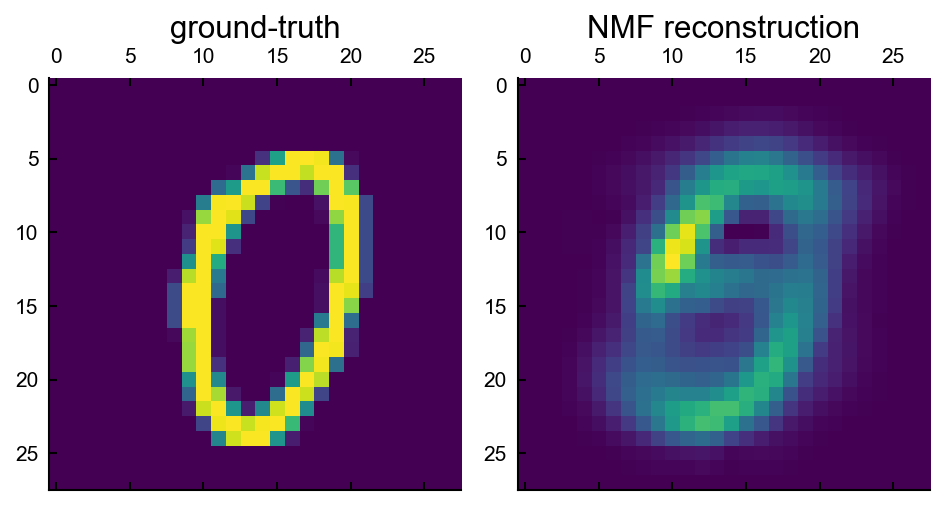

In [115]:
plt.style.use('../JS.mplstyle')
fig, ax = plt.subplots(1, 2)
image = 1000

ax[0].matshow(X[image].reshape(28, 28))
ax[1].matshow((W @ H)[image].reshape(28, 28))

ax[1].set_title('NMF reconstruction')
ax[0].set_title('ground-truth')

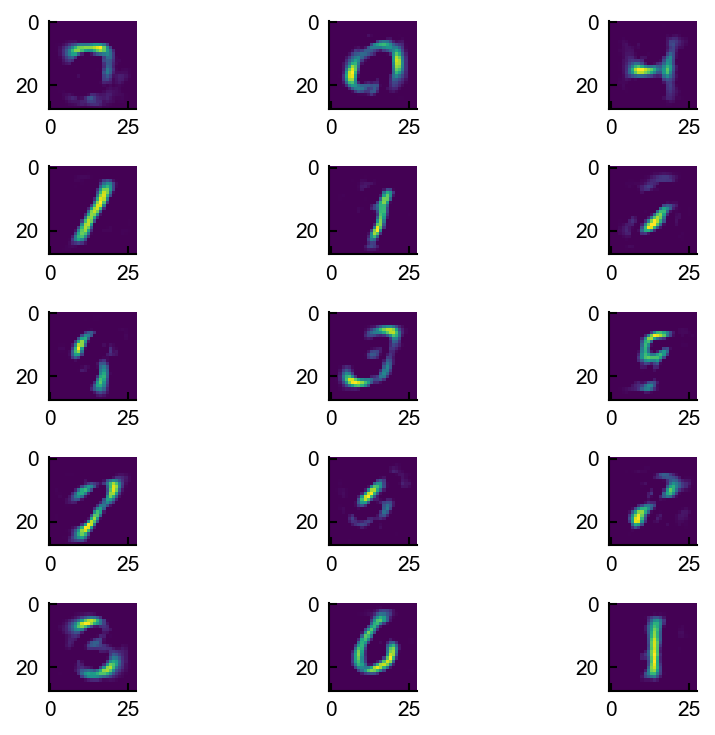

In [95]:
fig, ax = plt.subplots(5, 3, figsize=(8, 5))
for i in range(15):
    # print(i % 3)
    # print(i // 3)
    ax[i//3, i % 3].imshow(H[i].reshape(28, 28))